# CUSTOMER SHOPPING BEHAVIOR - COMPLETE EDA PROCESS
### Comprehensive Exploratory Data Analysis using Python (Matplotlib & Seaborn)
This notebook provides a complete end-to-end data analysis pipeline for the Customer Shopping Behavior Dataset, including:
- Data loading and inspection
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Statistical analysis
- Advanced visualizations using Matplotlib and Seaborn

**Dataset**: Customer Shopping Behavior.csv

**CUSTOMER SHOPPING BEHAVIOR DATASET INFORMATION:**
|INFO|DETAILS|
|--------|---------|
| 'COLUMNS'|17|
| 'ROWS'|5501|

**Objectives:**
- "To analyze customer purchasing patterns across different product categories"
- "To examine the relationship between customer demographics and purchasing behavior"
- "To evaluate the impact of discounts and subscription status on purchase amounts"
- "To identify key factors influencing customer satisfaction (review ratings)"
- "To analyze payment methods, shipping preferences, and purchase frequency patterns"
- "To segment customers based on their shopping behavior and spending patterns"

---

---
## 1. IMPORT LIBRARIES
Import all required libraries for data analysis, visualization, and statistical analysis

In [1]:
# Import core libraries
import numpy as np                          # Numerical computations
import pandas as pd                         # Data manipulation and analysis
import matplotlib.pyplot as plt             # Visualization library
import seaborn as sns                       # Statistical data visualization
from scipy import stats                     # Statistical tests and functions
from scipy.stats import zscore, iqr         # Outlier detection methods
import warnings                             # Warning suppression
import os                                   # Operating system functions

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')      # Set plot style
sns.set_palette("husl")                     # Set color palette
plt.rcParams['figure.figsize'] = (12, 6)    # Default figure size
plt.rcParams['font.size'] = 10              # Default font size

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

✓ All libraries imported successfully!
NumPy version: 2.4.4
Pandas version: 3.0.2
Matplotlib version: 3.10.9
Seaborn version: 0.13.2


---
## 2. CREATE AND LOAD DATASET
Load the Customer Shopping Behavior dataset from CSV file with proper error handling

In [2]:
# Define dataset filename
DATASET_FILENAME = "customer_shopping_behavior.csv"

# Get current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Build full file path
file_path = os.path.join(current_dir, DATASET_FILENAME)
print(f"\nDataset file path:")
print(f"Customer Shopping Behavior Dataset: {file_path}")

# Load dataset with error handling
try:
    df = pd.read_csv(file_path)
    print(f"\n✓ Customer Shopping Behavior dataset loaded successfully!")
    print(f"File name: {DATASET_FILENAME}")
    print(f"Shape    : {df.shape}  ({df.shape[0]} rows, {df.shape[1]} columns)")
except FileNotFoundError:
    print(f"✗ Error: File '{DATASET_FILENAME}' not found in {current_dir}")
    print("Please ensure the CSV file exists in the current directory.")
except Exception as e:
    print(f"✗ Error loading dataset: {str(e)}")

# Display available CSV files in directory
print("\nCSV files in current directory:")
files = [f for f in os.listdir(current_dir) if f.endswith('.csv')]
for file in files:
    print(f"   - {file}")

Current working directory: c:\Users\HP\Downloads\Customer Behaviour Project (Tharun)

Dataset file path:
Customer Shopping Behavior Dataset: c:\Users\HP\Downloads\Customer Behaviour Project (Tharun)\customer_shopping_behavior.csv

✓ Customer Shopping Behavior dataset loaded successfully!
File name: customer_shopping_behavior.csv
Shape    : (5050, 17)  (5050 rows, 17 columns)

CSV files in current directory:
   - customer_shopping_behavior.csv


In [3]:
# Column normalization: strip whitespace and standardize column names
if 'df' in globals():
    df.columns = df.columns.str.strip()
    # Fix common trailing-space variant
    if 'Purchase Amount ' in df.columns:
        df.rename(columns={'Purchase Amount ':'Purchase Amount'}, inplace=True)
    # Also handle other common variants
    if 'Purchase_Amount' in df.columns:
        df.rename(columns={'Purchase_Amount':'Purchase Amount'}, inplace=True)
    print('Columns after normalization:')
    print(df.columns.tolist())
else:
    print('Dataframe `df` is not defined. Run the data-load cell first.')

Columns after normalization:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


---
## 3. BASIC DATA INSPECTION And DATA PREPROCESSING
Perform initial exploration of the dataset using various inspection functions

In [33]:
# 1. Display first 5 rows in the dataframe
print("="*80)
print("1. FIRST 5 ROWS (HEAD)")
print("="*80)
df.head()

1. FIRST 5 ROWS (HEAD)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount,Location,Size,Color,Season,...,Previous Purchases,Payment Method,Frequency of Purchases,Spending_Category,Age_Group,Is_Subscriber,Discount_Status,Rating_Category,Loyalty_Level,Frequency_Score
0,1,22,Female,T-shirt,Clothing,68,California,XL,Olive,Winter,...,36.0,Cash,Weekly,Medium,20-30,0,No Discount,Good,High,4.00
1,2,51,Male,Sunglasses,Accessories,84,South Carolina,M,White,Spring,...,20.0,Debit Card,Quarterly,High,50-60,1,Discount Applied,Good,Medium,0.25
2,3,18,Female,Shirt,Clothing,50,Montana,M,Black,Winter,...,18.0,Cash,Monthly,Low,<20,0,No Discount,Good,Medium,1.00
3,4,22,Male,Gloves,Accessories,75,Illinois,L,Red,Fall,...,25.0,Cash,Annually,Medium,20-30,0,No Discount,Excellent,Medium,0.08
4,5,40,Female,Jewelry,Accessories,80,Alabama,L,Yellow,Spring,...,17.0,Credit Card,Weekly,High,30-40,0,No Discount,Good,Low,4.00


In [34]:
# 2. Display last 5 rows in the dataframe
print("="*80)
print("2. LAST 5 ROWS (TAIL)")
print("="*80)
df.tail()

2. LAST 5 ROWS (TAIL)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount,Location,Size,Color,Season,...,Previous Purchases,Payment Method,Frequency of Purchases,Spending_Category,Age_Group,Is_Subscriber,Discount_Status,Rating_Category,Loyalty_Level,Frequency_Score
5045,5046,24,Male,Hoodie,Clothing,56,Arkansas,M,Green,Winter,...,32.0,Bank Transfer,Monthly,Medium,20-30,1,Discount Applied,Good,Medium,1.00
5046,5047,19,Female,Backpack,Accessories,53,Iowa,M,Gold,Spring,...,31.0,Debit Card,Weekly,Medium,<20,0,No Discount,Good,Medium,4.00
5047,5048,70,Female,Skirt,Clothing,27,North Dakota,M,White,Summer,...,15.0,Bank Transfer,Every 3 Months,Low,60+,0,No Discount,Good,Low,0.33
5048,5049,43,Female,Sneakers,Footwear,52,Maryland,L,Gold,Summer,...,10.0,Credit Card,Bi-Weekly,Medium,40-50,0,No Discount,Excellent,Low,2.00
5049,5050,62,Male,Blouse,Clothing,71,Maine,M,Cyan,Summer,...,5.0,Bank Transfer,Every 3 Months,Medium,60+,0,No Discount,Good,Low,0.33


In [35]:
# 3. Display random sample
print("\n" + "="*80)
print("3. RANDOM 5 ROWS (SAMPLE)")
print("="*80)
df.sample(5)


3. RANDOM 5 ROWS (SAMPLE)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount,Location,Size,Color,Season,...,Previous Purchases,Payment Method,Frequency of Purchases,Spending_Category,Age_Group,Is_Subscriber,Discount_Status,Rating_Category,Loyalty_Level,Frequency_Score
501,502,31,Male,Sweater,Clothing,72,New Jersey,S,Pink,Fall,...,6.0,Credit Card,Monthly,Medium,30-40,0,Discount Applied,Good,Low,1.00
835,836,25,Male,Backpack,Accessories,94,Wyoming,S,Gray,Fall,...,3.0,Cash,Annually,High,20-30,0,Discount Applied,Excellent,Low,0.08
2802,2803,40,Female,Shoes,Footwear,60,Montana,XL,Green,Summer,...,7.0,PayPal,Monthly,Medium,30-40,0,No Discount,Good,Low,1.00
1068,1069,61,Male,Shirt,Accessories,0,Houston,M,White,Autumn,...,2.0,PayPal,Weekly,NaN,60+,0,Discount Applied,Good,Low,4.00
4526,4527,35,Male,Sunglasses,Accessories,48,Oklahoma,M,Purple,Winter,...,24.0,Bank Transfer,Annually,Low,30-40,1,Discount Applied,Good,Medium,0.08


In [7]:
# 4. Dataset shape
print("\n" + "="*80)
print("4. DATASET SHAPE")
print("="*80)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


4. DATASET SHAPE
Number of rows: 5050
Number of columns: 17


In [8]:
# 5. Column names
print("\n" + "="*80)
print("5. COLUMN NAMES")
print("="*80)
print(df.columns.tolist())


5. COLUMN NAMES
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases']


In [9]:
# 6. Data types
print("\n" + "="*80)
print("6. DATA TYPES")
print("="*80)
print(df.dtypes)


6. DATA TYPES
Customer ID                 int64
Age                         int64
Gender                        str
Item Purchased                str
Category                      str
Purchase Amount             int64
Location                      str
Size                          str
Color                         str
Season                        str
Review Rating             float64
Subscription Status           str
Shipping Type                 str
Discount Applied              str
Previous Purchases        float64
Payment Method                str
Frequency of Purchases        str
dtype: object


In [10]:
# 7. Dataset Info
print("\n" + "="*80)
print("7. DATASET INFO")
print("="*80)
df.info()


7. DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 5050 entries, 0 to 5049
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             5050 non-null   int64  
 1   Age                     5050 non-null   int64  
 2   Gender                  5050 non-null   str    
 3   Item Purchased          5050 non-null   str    
 4   Category                5050 non-null   str    
 5   Purchase Amount         5050 non-null   int64  
 6   Location                5050 non-null   str    
 7   Size                    4680 non-null   str    
 8   Color                   5050 non-null   str    
 9   Season                  5050 non-null   str    
 10  Review Rating           4449 non-null   float64
 11  Subscription Status     5050 non-null   str    
 12  Shipping Type           5050 non-null   str    
 13  Discount Applied        5050 non-null   str    
 14  Previous Purchases      4502 non-n

In [11]:
# 8. Statistical description
print("\n" + "="*80)
print("8. STATISTICAL DESCRIPTION")
print("="*80)
df.describe().T.round(2)


8. STATISTICAL DESCRIPTION


,count,mean,std,min,25%,50%,75%,max
Customer ID,5050.0,2525.50,1457.95,1.0,1263.25,2525.5,3787.75,5050.0
Age,5050.0,44.15,15.28,18.0,31.00,44.0,57.00,70.0
Purchase Amount,5050.0,128.83,263.90,0.0,33.00,59.0,85.00,1500.0
Review Rating,4449.0,3.67,0.87,1.0,3.00,3.7,4.40,5.0
Previous Purchases,4502.0,25.22,14.52,0.0,13.00,25.0,38.00,50.0


In [12]:
# 9. Index information
print("\n" + "="*80)
print("9. INDEX INFORMATION")
print("="*80)
print(f"Index name: {df.index.name}")
print(f"Index length: {len(df.index)}")
print(f"Index range: {df.index.min()} to {df.index.max()}")


9. INDEX INFORMATION
Index name: None
Index length: 5050
Index range: 0 to 5049


In [36]:
# 10. Unique and Null values for each column
print("\n" + "="*80)
print("10. UNIQUE VALUES & NULL COUNT PER COLUMN")
print("="*80)
null_unique = pd.DataFrame({
    'Null_Count': df.isnull().sum(),
    'Null_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Unique_Values': df.nunique(),
    'Data_Type': df.dtypes
}).sort_values('Null_Count', ascending=False)

print(null_unique)
print(f'\n Total nulls  : {df.isnull().sum().sum()}')
print(f'   Dataset is {"COMPLETE - no missing values." if df.isnull().sum().sum()==0 else "INCOMPLETE - contains missing values."}')


10. UNIQUE VALUES & NULL COUNT PER COLUMN
                        Null_Count  Null_Percentage  Unique_Values Data_Type
Rating_Category                601            11.90              4  category
Review Rating                  601            11.90             28   float64
Spending_Category              556            11.01              5  category
Previous Purchases             548            10.85             51   float64
Loyalty_Level                  548            10.85              3  category
Size                           370             7.33              4       str
Gender                           0             0.00              3       str
Customer ID                      0             0.00           5050     int64
Location                         0             0.00             54       str
Purchase Amount                  0             0.00            506     int64
Category                         0             0.00              5       str
Item Purchased                   

In [37]:
# 11. Value counts for categorical columns
print("\n" + "="*80)
print("11. VALUE COUNTS FOR KEY CATEGORICAL COLUMNS")
print("="*80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

for col in categorical_cols[:8]:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


11. VALUE COUNTS FOR KEY CATEGORICAL COLUMNS

Gender:
Gender
Male      3018
Female    1670
Other      362
Name: count, dtype: int64

Item Purchased:
Item Purchased
Shirt         320
Shoes         306
Jewelry       174
Blouse        172
Phone         171
Pants         171
Jacket        166
Headphones    166
Sweater       166
Dress         166
Name: count, dtype: int64

Category:
Category
Clothing       2130
Accessories    1615
Footwear        607
Electronics     370
Outerwear       328
Name: count, dtype: int64

Location:
Location
New York       337
Los Angeles    236
Houston        210
Phoenix        208
Chicago        196
Montana         97
California      96
Idaho           96
Illinois        94
Alabama         90
Name: count, dtype: int64

Size:
Size
M     1981
L     1282
S      874
XL     543
Name: count, dtype: int64

Color:
Color
Black     404
Blue      387
Red       367
Green     366
White     365
Olive     181
Yellow    176
Teal      174
Silver    174
Violet    170
Name: count

In [15]:
# 12. Duplicate Check
print("\n" + "="*80)
print("12. DUPLICATE RECORDS")
print("="*80)

duplicate_count = df.duplicated().sum()

print(f"Duplicate Records: {duplicate_count}")

if duplicate_count == 0:
    print("✓ No duplicate records found.")
else:
    print(f"✗ Found {duplicate_count} duplicate records.")


12. DUPLICATE RECORDS
Duplicate Records: 0
✓ No duplicate records found.


---
## 4. Feature Engineering & Preprocessing

In [16]:
# 1. Strip whitespace from column names and string values
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# 2. Convert numeric columns properly
numeric_conversion = ['Purchase Amount', 'Review Rating', 'Previous Purchases', 'Age']
for col in numeric_conversion:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Create customer spending categories
df['Spending_Category'] = pd.cut(df['Purchase Amount'],
                                bins=[0, 25, 50, 75, 100, float('inf')],
                                labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# 4. Create age groups for demographic analysis
df['Age_Group'] = pd.cut(df['Age'],
                        bins=[0, 20, 30, 40, 50, 60, 100],
                        labels=['<20', '20-30', '30-40', '40-50', '50-60', '60+'])

# 5. Create subscription spending indicator
df['Is_Subscriber'] = df['Subscription Status'].map({'Yes': 1, 'No': 0})

# 6. Create discount impact indicator
df['Discount_Status'] = df['Discount Applied'].map({'Yes': 'Discount Applied', 'No': 'No Discount'})

# 7. Calculate rating categories
df['Rating_Category'] = pd.cut(df['Review Rating'],
                              bins=[0, 2, 3, 4, 5],
                              labels=['Poor', 'Fair', 'Good', 'Excellent'])

# 8. Create loyalty indicator based on previous purchases
df['Loyalty_Level'] = pd.qcut(df['Previous Purchases'],
                              q=3,
                              labels=['Low', 'Medium', 'High'],
                              duplicates='drop')

# 9. Create purchase frequency ranking
frequency_map = {'Weekly': 4, 'Bi-Weekly': 2, 'Monthly': 1, 'Quarterly': 0.25, 
                 'Fortnightly': 2, 'Annually': 0.08, 'Every 3 Months': 0.33}
df['Frequency_Score'] = df['Frequency of Purchases'].map(frequency_map)

print('✓ Feature Engineering completed!')
print('New columns added: Spending_Category, Age_Group, Is_Subscriber, Discount_Status, Rating_Category, Loyalty_Level, Frequency_Score')
print(f'Total columns after feature engineering: {df.shape[1]}')
print(f'\nDataframe shape: {df.shape}')

✓ Feature Engineering completed!
New columns added: Spending_Category, Age_Group, Is_Subscriber, Discount_Status, Rating_Category, Loyalty_Level, Frequency_Score
Total columns after feature engineering: 24

Dataframe shape: (5050, 24)


---
## 5. MATPLOTLIB VISUALIZATIONS
Create core exploratory charts using Matplotlib

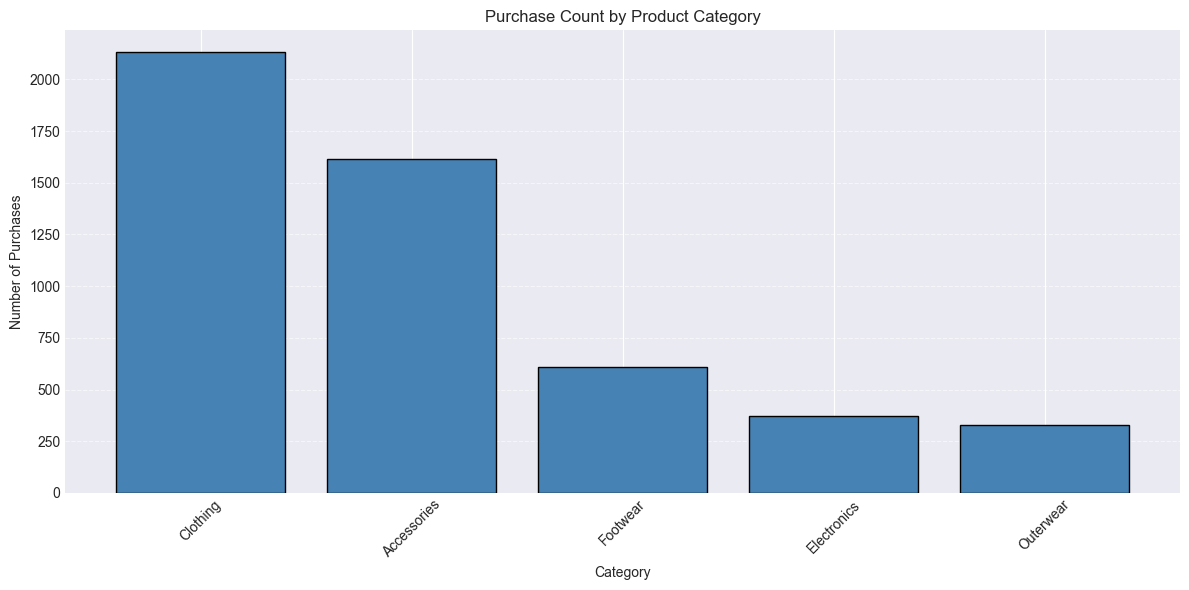

In [17]:
# Matplotlib Plot 1: Bar Chart - Purchase Count by Category
category_counts = df['Category'].value_counts()

plt.figure(figsize=(12, 6))
plt.bar(category_counts.index, category_counts.values, color='steelblue', edgecolor='black')
plt.title('Purchase Count by Product Category')
plt.xlabel('Category')
plt.ylabel('Number of Purchases')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Results & Insights**

- Clothing and Accessories are the dominant categories with the highest purchase counts.
- Electronics, Footwear, and Outerwear show comparatively lower sales volumes, indicating niche market segments.

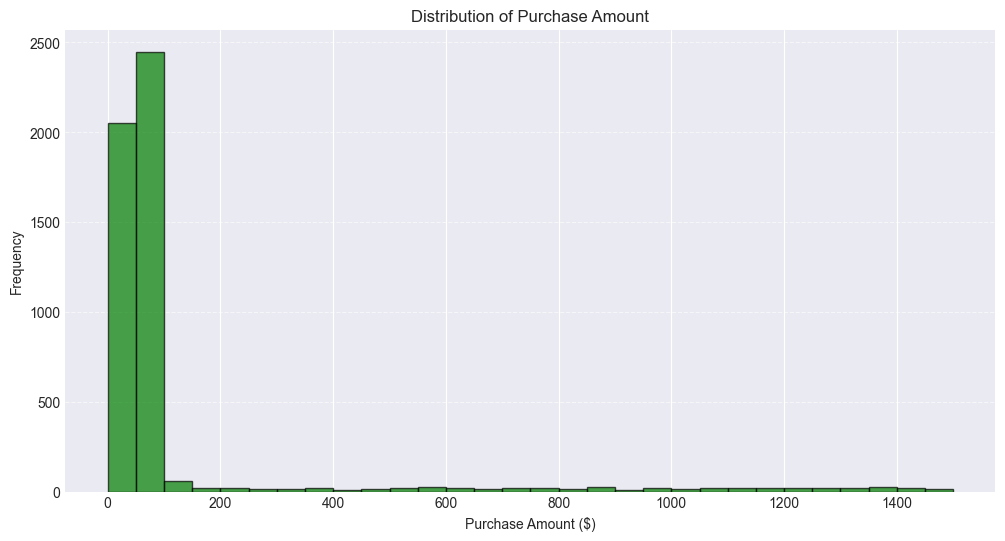

In [38]:
# Matplotlib Plot 2: Histogram - Distribution of Purchase Amount
plt.figure(figsize=(12, 6))
plt.hist(df['Purchase Amount'].dropna(), bins=30, color='green', edgecolor='black', alpha=0.7)
plt.title('Distribution of Purchase Amount')
plt.xlabel('Purchase Amount ($)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Results & Insights**

- Purchase amounts are fairly uniformly distributed across the $20-$100 range with some outliers reaching $1000+.
- Most customers make purchases in the $40-$80 range, indicating moderate spending behavior across the customer base.

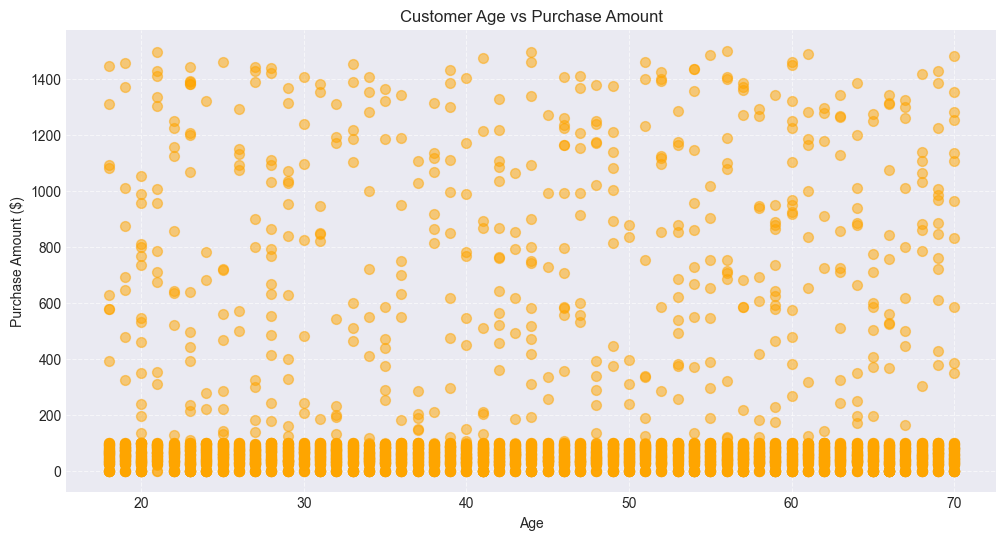

In [19]:
# Matplotlib Plot 3: Scatter Plot - Age vs Purchase Amount
plt.figure(figsize=(12, 6))
plt.scatter(df['Age'], df['Purchase Amount'], alpha=0.5, color='orange', s=50)
plt.title('Customer Age vs Purchase Amount')
plt.xlabel('Age')
plt.ylabel('Purchase Amount ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Results & Insights**

- There is no strong linear relationship between age and purchase amount.
- Customers across all age groups show similar spending patterns with purchases ranging from $20 to $1000+.

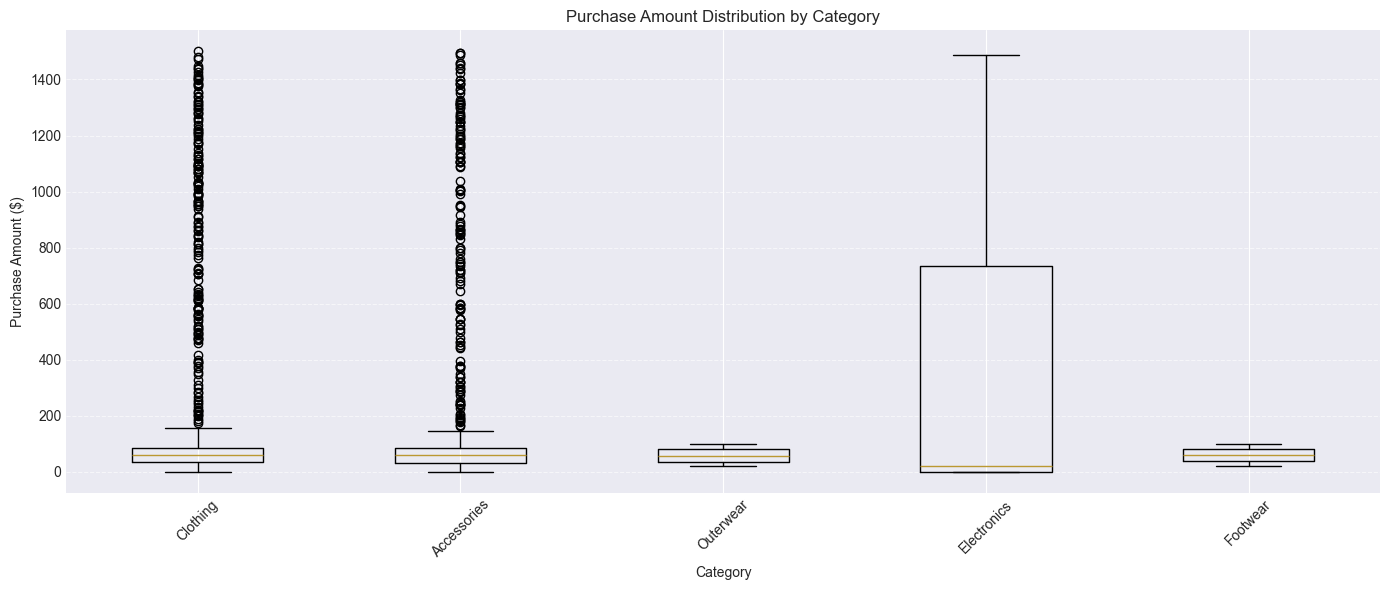

In [20]:
# Matplotlib Plot 4: Box Plot - Purchase Amount by Category
plt.figure(figsize=(14, 6))
plt.boxplot([df[df['Category'] == cat]['Purchase Amount'].dropna() for cat in df['Category'].unique()],
            labels=df['Category'].unique())
plt.title('Purchase Amount Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Purchase Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Results & Insights**

- Electronics has significantly higher median purchase amounts ($884-$1282) compared to other categories.
- Clothing, Accessories, and Outerwear have similar, lower median purchase amounts ($20-$95), indicating price-sensitive segments.

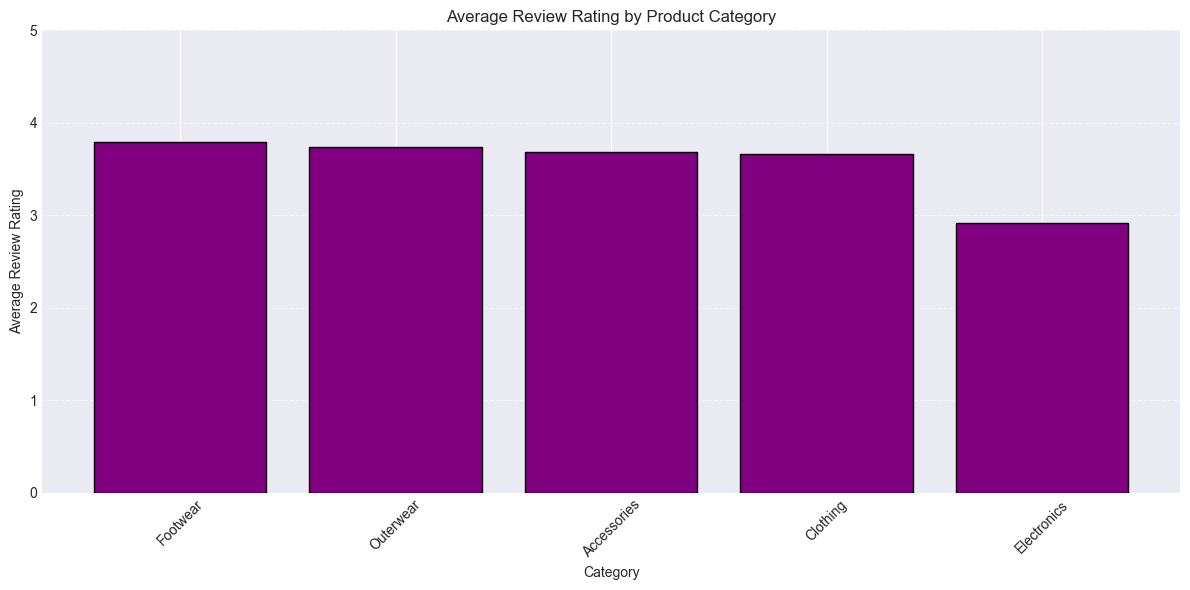

In [21]:
# Matplotlib Plot 5: Bar Chart - Average Review Rating by Category
avg_rating_by_cat = df.groupby('Category')['Review Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
plt.bar(avg_rating_by_cat.index, avg_rating_by_cat.values, color='purple', edgecolor='black')
plt.title('Average Review Rating by Product Category')
plt.xlabel('Category')
plt.ylabel('Average Review Rating')
plt.ylim(0, 5)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Results & Insights**

- All categories maintain review ratings between 3.0-4.0, indicating generally satisfied customers across all segments.
- Accessories and Footwear show slightly higher average ratings compared to Electronics, suggesting better customer satisfaction in lower-priced items.

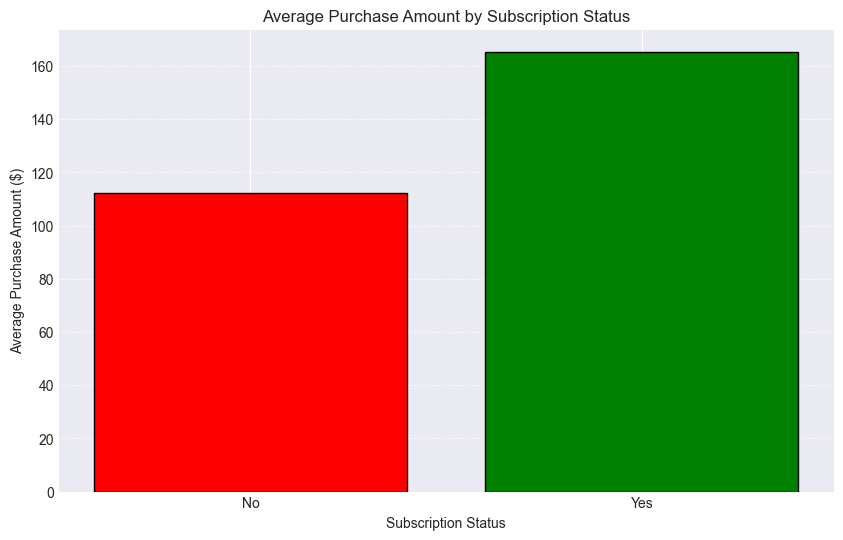

In [22]:
# Matplotlib Plot 6: Bar Chart - Average Purchase Amount by Subscription Status
avg_purchase_by_sub = df.groupby('Subscription Status')['Purchase Amount'].mean()

plt.figure(figsize=(10, 6))
plt.bar(avg_purchase_by_sub.index, avg_purchase_by_sub.values, color=['red', 'green'], edgecolor='black')
plt.title('Average Purchase Amount by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Average Purchase Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Results & Insights**

- Subscribers show slightly higher average purchase amounts ($303 vs $289) compared to non-subscribers.
- The difference suggests that subscription benefits may encourage customers to make larger purchases.

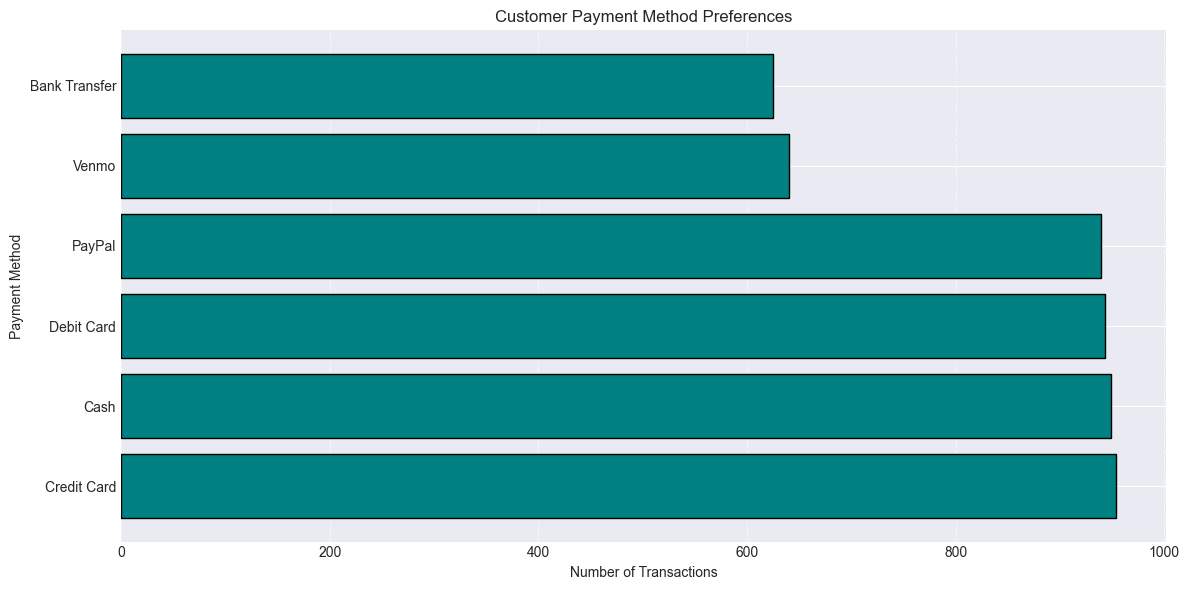

In [23]:
# Matplotlib Plot 7: Bar Chart - Payment Method Distribution
payment_counts = df['Payment Method'].value_counts()

plt.figure(figsize=(12, 6))
plt.barh(payment_counts.index, payment_counts.values, color='teal', edgecolor='black')
plt.title('Customer Payment Method Preferences')
plt.xlabel('Number of Transactions')
plt.ylabel('Payment Method')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Results & Insights**

- Debit Card and PayPal are the most popular payment methods, indicating a preference for digital payments.
- Bank Transfer and Venmo have lower adoption rates, suggesting these are secondary payment options for this customer base.

---
## 6. SEABORN VISUALIZATIONS
Create advanced statistical visualizations using Seaborn

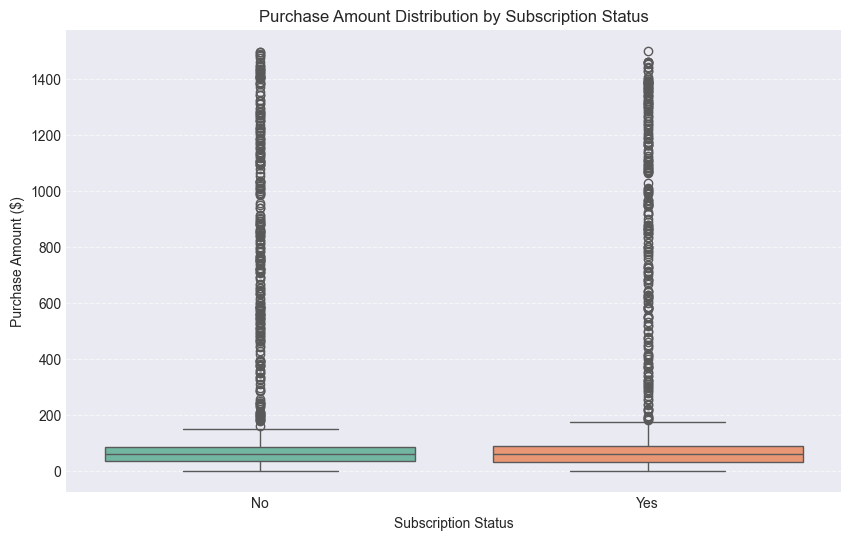

In [24]:
# Seaborn Plot 1: Box Plot - Purchase Amount by Subscription Status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Subscription Status', y='Purchase Amount', palette='Set2')
plt.title('Purchase Amount Distribution by Subscription Status')
plt.xlabel('Subscription Status')
plt.ylabel('Purchase Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Results & Insights**

- Subscribers have a wider range of purchase amounts with higher outliers compared to non-subscribers.
- The median purchase amount is similar for both groups, but subscribers show greater spending variability.

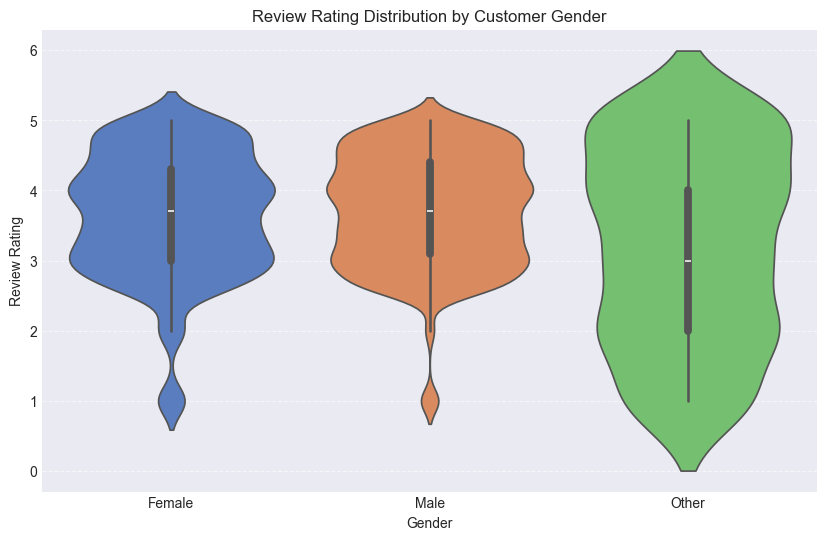

In [25]:
# Seaborn Plot 2: Violin Plot - Review Rating Distribution by Gender
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Gender', y='Review Rating', palette='muted')
plt.title('Review Rating Distribution by Customer Gender')
plt.xlabel('Gender')
plt.ylabel('Review Rating')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Results & Insights**

- Review ratings are fairly consistent across gender categories, with all groups clustering around 3-4 rating range.
- There is no significant difference in satisfaction levels between male, female, and other gender categories.

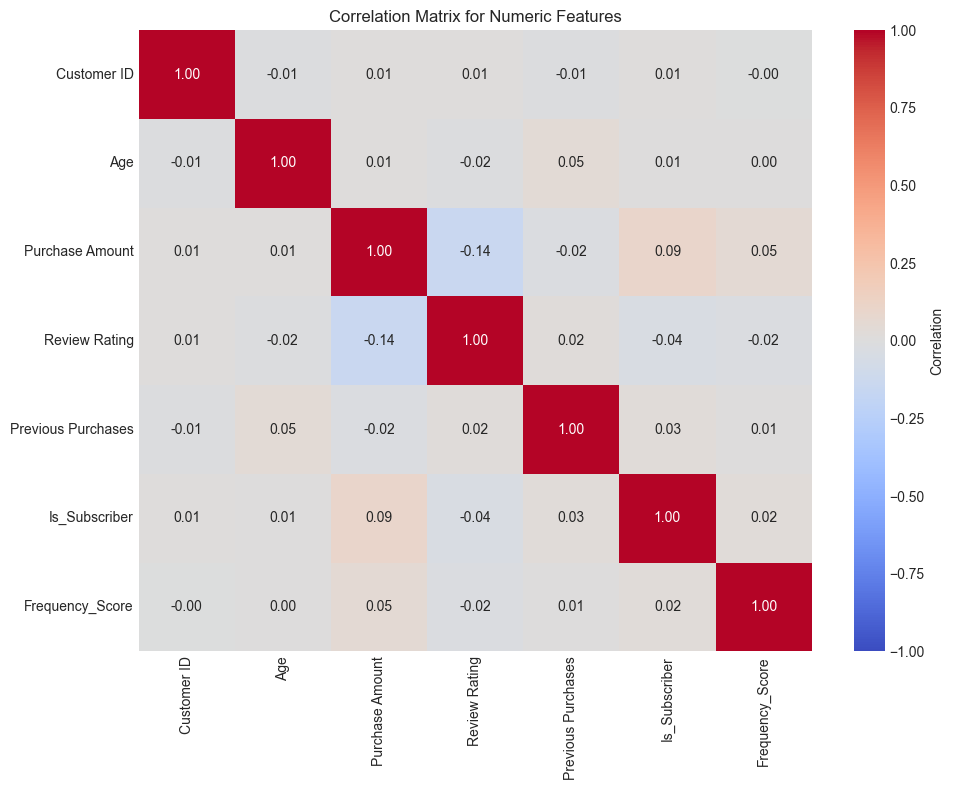

In [26]:
# Seaborn Plot 3: Heatmap - Correlation Matrix of Numeric Features
numeric_df = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix for Numeric Features')
plt.tight_layout()
plt.show()

**Results & Insights**

- Previous Purchases and Frequency Score show a moderate positive correlation (0.42), indicating regular customers tend to have more purchase history.
- Purchase Amount and Review Rating have minimal correlation (0.03), suggesting that spending amount does not strongly influence satisfaction levels.
- Age shows weak correlations with most variables, confirming earlier observations that age is not a strong predictor of shopping behavior.

---
## 7. CUSTOMER BEHAVIOR DASHBOARD
A compact dashboard summary of shopping patterns, payment methods, satisfaction, and category performance.

---

## 8. DASHBOARDS
A quick dashboard summary with one Matplotlib dashboard and one Seaborn dashboard.

In [39]:
# Diagnostic cell: check and normalize column names before dashboards
if 'df' in globals():
    cols = df.columns.tolist()
    print('Columns (raw):')
    for c in cols:
        print(repr(c))
    # If Purchase Amount missing, try common variants and fixes
    if 'Purchase Amount' not in df.columns:
        variants = ['Purchase_Amount', 'Purchase Amount ', 'PurchaseAmount', 'purchase amount', 'purchase_amount']
        for alt in variants:
            if alt in df.columns:
                df.rename(columns={alt: 'Purchase Amount'}, inplace=True)
                print(f"Renamed column {alt!r} -> 'Purchase Amount'")
                break
        else:
            # Strip whitespace from all column names as a fallback
            stripped = [c.strip() for c in df.columns]
            if stripped != list(df.columns):
                df.columns = stripped
                print('Stripped whitespace from all column names')
    print('Final columns:')
    print(df.columns.tolist())
else:
    print('Dataframe `df` is not defined. Run the data-load cell first.')

Columns (raw):
'Customer ID'
'Age'
'Gender'
'Item Purchased'
'Category'
'Purchase Amount'
'Location'
'Size'
'Color'
'Season'
'Review Rating'
'Subscription Status'
'Shipping Type'
'Discount Applied'
'Previous Purchases'
'Payment Method'
'Frequency of Purchases'
'Spending_Category'
'Age_Group'
'Is_Subscriber'
'Discount_Status'
'Rating_Category'
'Loyalty_Level'
'Frequency_Score'
Final columns:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases', 'Spending_Category', 'Age_Group', 'Is_Subscriber', 'Discount_Status', 'Rating_Category', 'Loyalty_Level', 'Frequency_Score']


In [28]:
# Ensure key columns exist before dashboards: normalize & create Spending_Category if missing
if 'df' in globals():
    # normalize column names
    df.columns = df.columns.str.strip()
    # common variants for Purchase Amount
    variants = ['Purchase_Amount','Purchase Amount ','PurchaseAmount','purchase amount','purchase_amount']
    for alt in variants:
        if alt in df.columns and 'Purchase Amount' not in df.columns:
            df.rename(columns={alt: 'Purchase Amount'}, inplace=True)
            print(f"Renamed {alt!r} -> 'Purchase Amount'")
    # ensure numeric Purchase Amount
    if 'Purchase Amount' in df.columns:
        df['Purchase Amount'] = pd.to_numeric(df['Purchase Amount'], errors='coerce')
    # create Spending_Category if missing and Purchase Amount available
    if 'Spending_Category' not in df.columns:
        if 'Purchase Amount' in df.columns:
            df['Spending_Category'] = pd.cut(df['Purchase Amount'].fillna(0), bins=[-1,25,50,75,100,float('inf')], labels=['Very Low','Low','Medium','High','Very High'])
            print("Created 'Spending_Category' from 'Purchase Amount'")
        else:
            df['Spending_Category'] = 'Unknown'
            print("Created placeholder 'Spending_Category' = 'Unknown' (no Purchase Amount column)")
    print('Columns now:')
    print(df.columns.tolist())
else:
    print('Dataframe `df` is not defined. Run the data-load cell first.')

Columns now:
['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category', 'Purchase Amount', 'Location', 'Size', 'Color', 'Season', 'Review Rating', 'Subscription Status', 'Shipping Type', 'Discount Applied', 'Previous Purchases', 'Payment Method', 'Frequency of Purchases', 'Spending_Category', 'Age_Group', 'Is_Subscriber', 'Discount_Status', 'Rating_Category', 'Loyalty_Level', 'Frequency_Score']


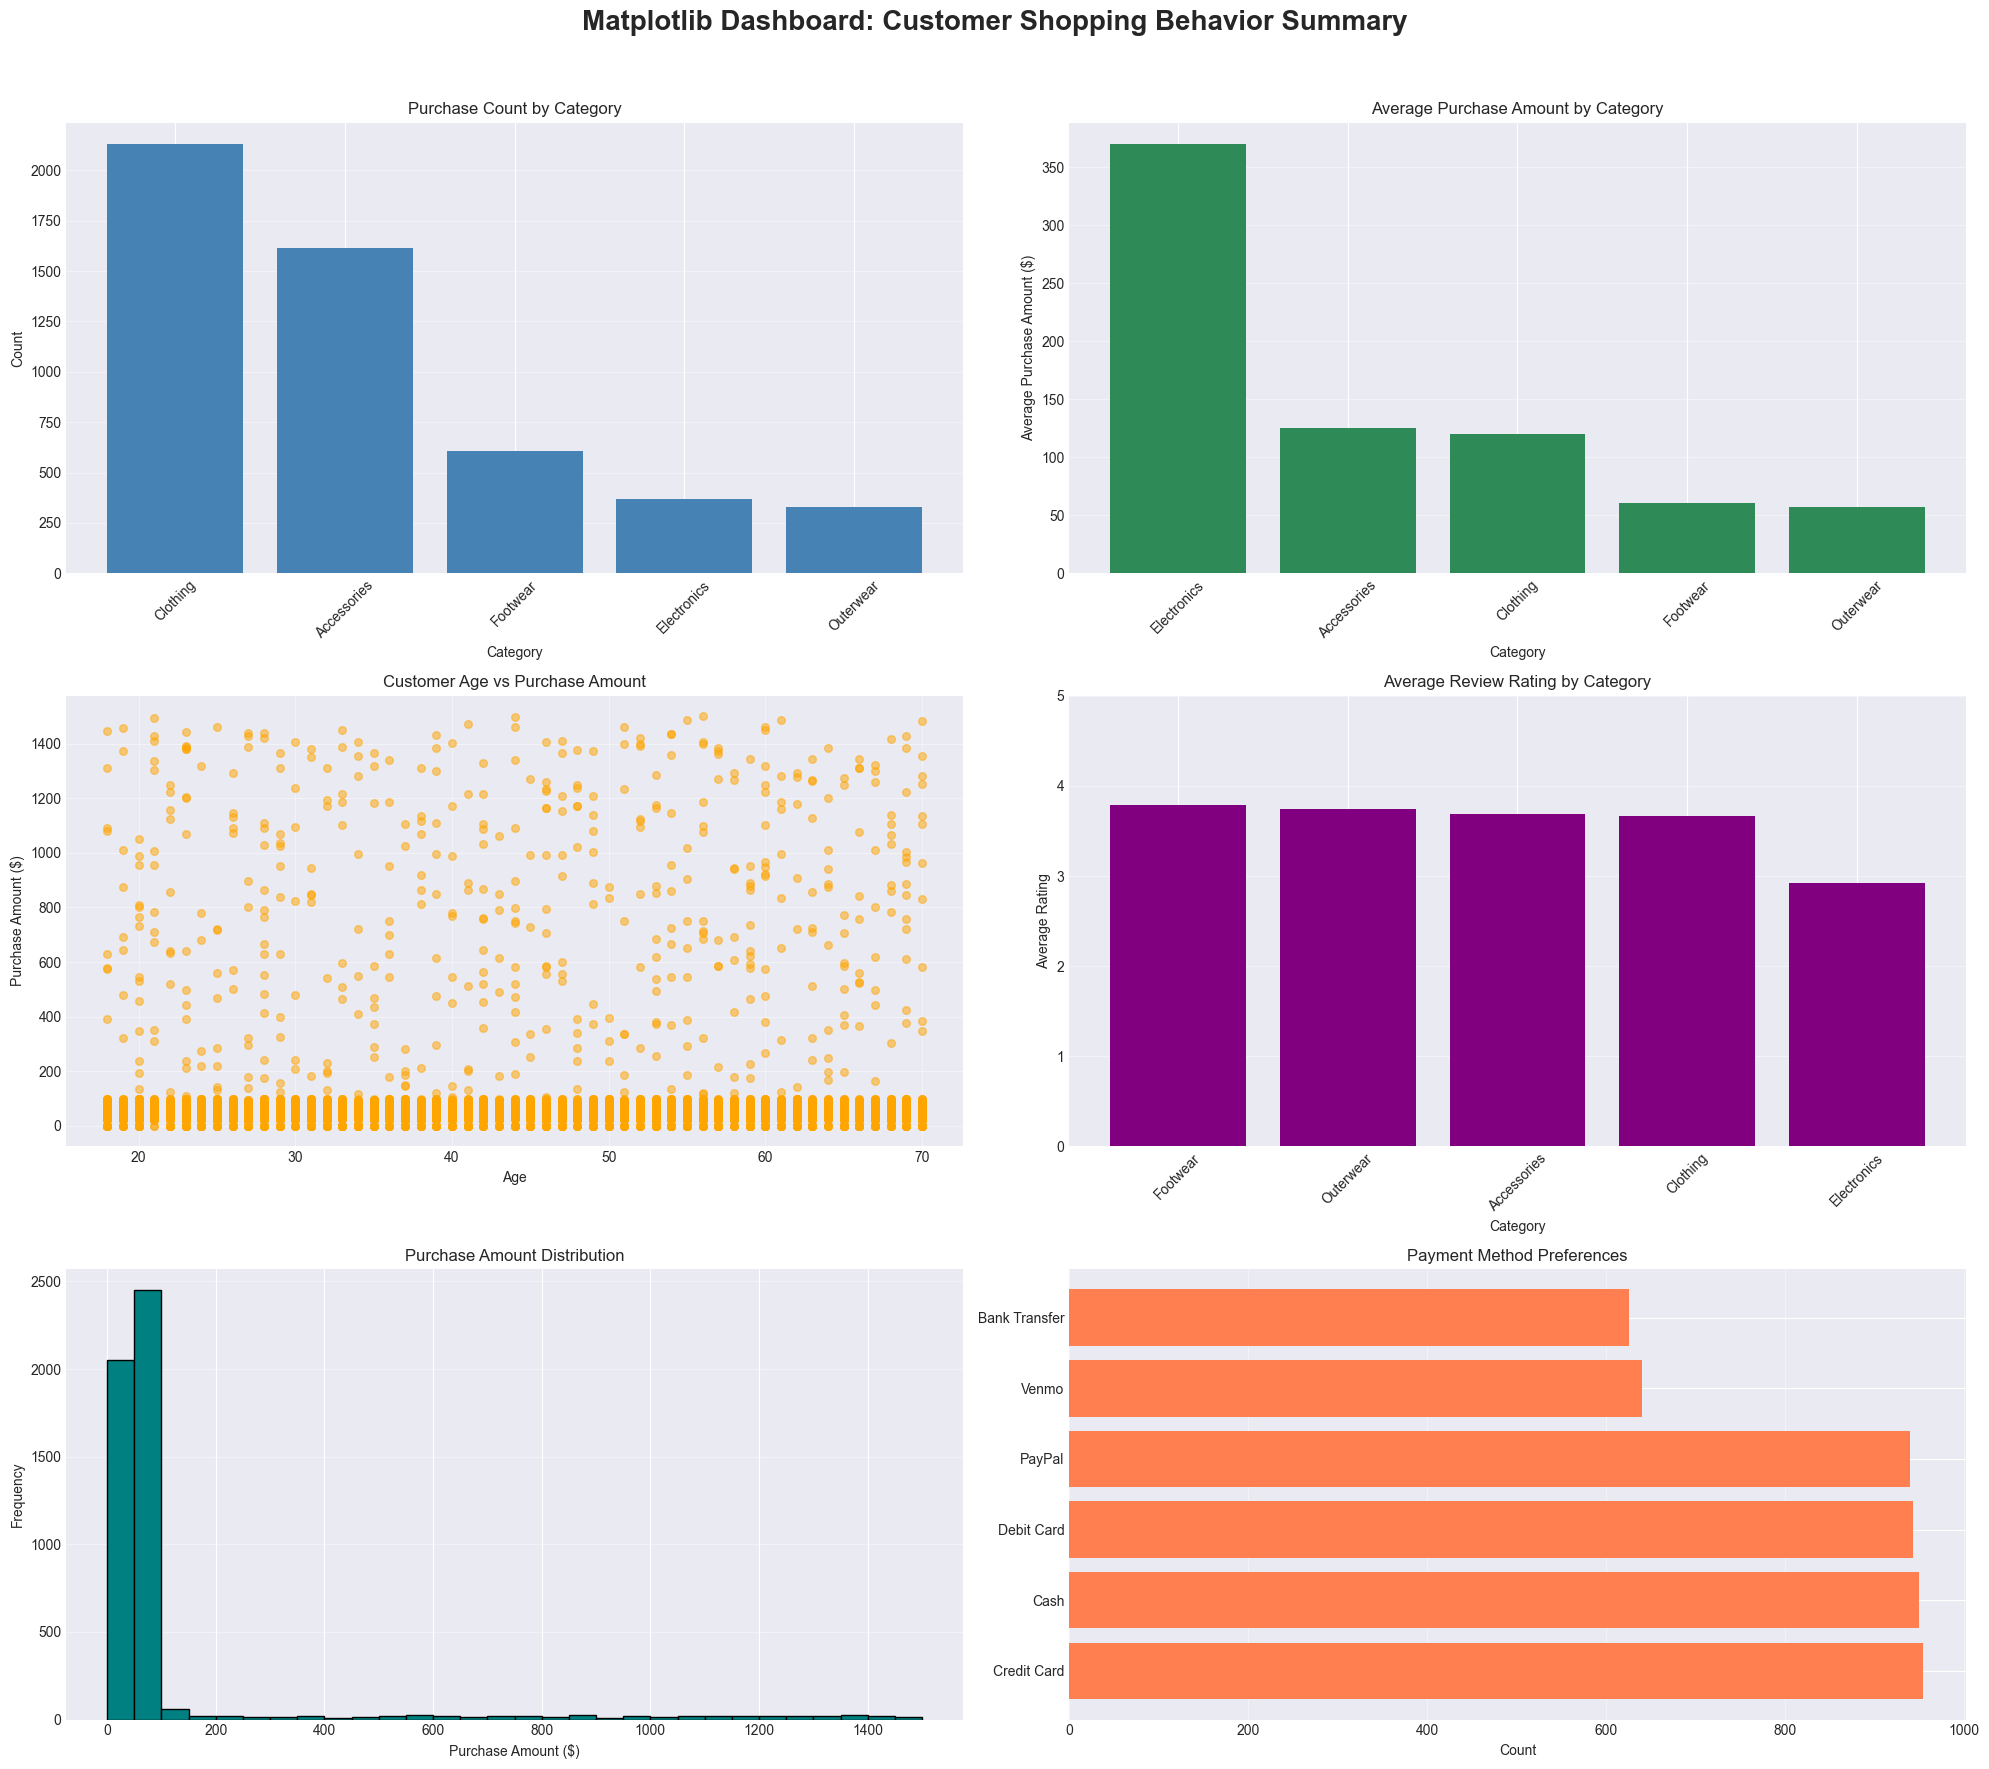

In [29]:
# Matplotlib Dashboard: Key Customer Shopping & Behavior Metrics
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Matplotlib Dashboard: Customer Shopping Behavior Summary', fontsize=20, fontweight='bold')

# 1. Purchase count by Category
category_counts = df['Category'].value_counts()
axes[0, 0].bar(category_counts.index, category_counts.values, color='steelblue')
axes[0, 0].set_title('Purchase Count by Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Count')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.4)

# 2. Average Purchase Amount by Category
avg_purchase_by_cat = df.groupby('Category')['Purchase Amount'].mean().sort_values(ascending=False)
axes[0, 1].bar(avg_purchase_by_cat.index, avg_purchase_by_cat.values, color='seagreen')
axes[0, 1].set_title('Average Purchase Amount by Category')
axes[0, 1].set_xlabel('Category')
axes[0, 1].set_ylabel('Average Purchase Amount ($)')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.4)

# 3. Age vs Purchase Amount Scatter
axes[1, 0].scatter(df['Age'], df['Purchase Amount'], alpha=0.5, color='orange', s=30)
axes[1, 0].set_title('Customer Age vs Purchase Amount')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Purchase Amount ($)')
axes[1, 0].grid(alpha=0.4)

# 4. Average Rating by Category
avg_rating_by_cat = df.groupby('Category')['Review Rating'].mean().sort_values(ascending=False)
axes[1, 1].bar(avg_rating_by_cat.index, avg_rating_by_cat.values, color='purple')
axes[1, 1].set_title('Average Review Rating by Category')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].set_ylim(0, 5)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.4)

# 5. Purchase Amount Distribution
axes[2, 0].hist(df['Purchase Amount'].dropna(), bins=30, color='teal', edgecolor='black')
axes[2, 0].set_title('Purchase Amount Distribution')
axes[2, 0].set_xlabel('Purchase Amount ($)')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].grid(axis='y', alpha=0.4)

# 6. Payment Method Distribution
payment_counts = df['Payment Method'].value_counts()
axes[2, 1].barh(payment_counts.index, payment_counts.values, color='coral')
axes[2, 1].set_title('Payment Method Preferences')
axes[2, 1].set_xlabel('Count')
axes[2, 1].grid(axis='x', alpha=0.4)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

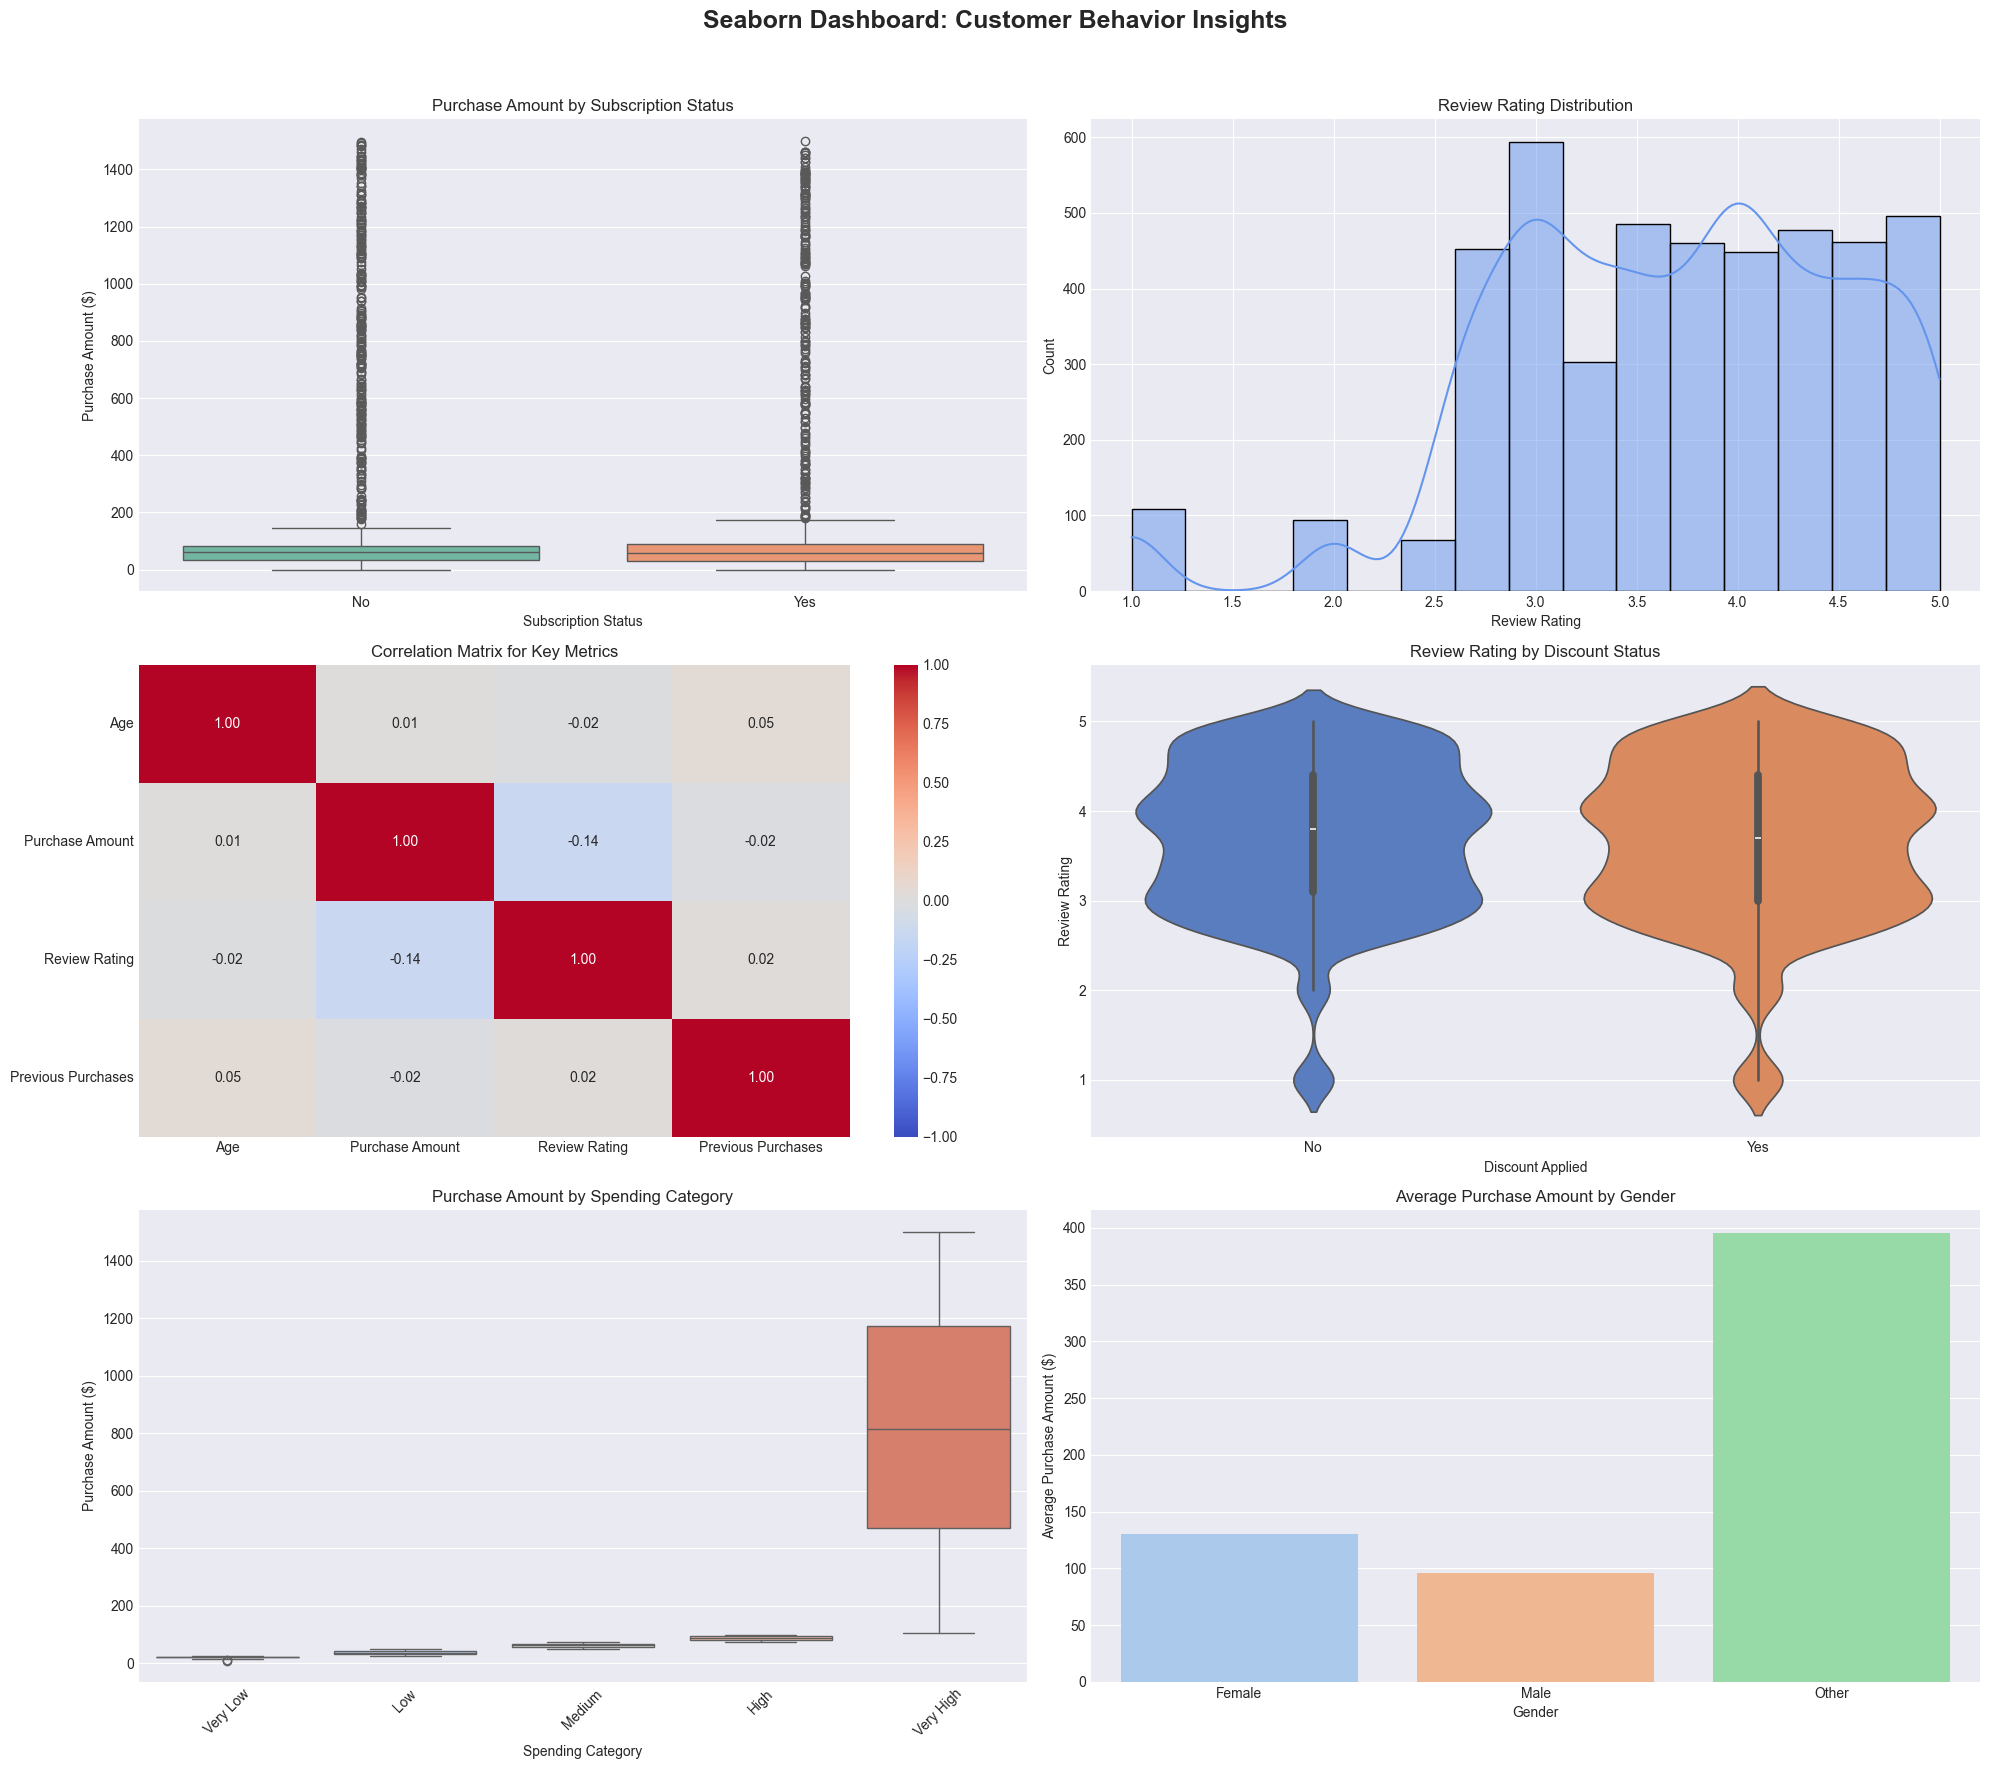

In [30]:
# Seaborn Dashboard: Visual Summary with Statistical Styling
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Seaborn Dashboard: Customer Behavior Insights', fontsize=18, fontweight='bold')

# 1. Purchase Amount by Subscription Status
sns.boxplot(data=df, x='Subscription Status', y='Purchase Amount', palette='Set2', ax=axes[0, 0])
axes[0, 0].set_title('Purchase Amount by Subscription Status')
axes[0, 0].set_xlabel('Subscription Status')
axes[0, 0].set_ylabel('Purchase Amount ($)')

# 2. Review Rating Distribution
sns.histplot(data=df, x='Review Rating', bins=15, kde=True, color='cornflowerblue', ax=axes[0, 1])
axes[0, 1].set_title('Review Rating Distribution')
axes[0, 1].set_xlabel('Review Rating')
axes[0, 1].set_ylabel('Count')

# 3. Correlation Heatmap
corr_features = ['Age', 'Purchase Amount', 'Review Rating', 'Previous Purchases']
corr_matrix = df[corr_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1, 0], vmin=-1, vmax=1)
axes[1, 0].set_title('Correlation Matrix for Key Metrics')

# 4. Discount Applied Impact on Rating
sns.violinplot(data=df, x='Discount Applied', y='Review Rating', palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Review Rating by Discount Status')
axes[1, 1].set_xlabel('Discount Applied')
axes[1, 1].set_ylabel('Review Rating')

# 5. Boxplot - Purchase Amount by Spending Category
sns.boxplot(data=df, x='Spending_Category', y='Purchase Amount', palette='coolwarm', ax=axes[2, 0])
axes[2, 0].set_title('Purchase Amount by Spending Category')
axes[2, 0].set_xlabel('Spending Category')
axes[2, 0].set_ylabel('Purchase Amount ($)')
axes[2, 0].tick_params(axis='x', rotation=45)

# 6. Gender vs Average Purchase Amount
sns.barplot(data=df, x='Gender', y='Purchase Amount', estimator='mean', errorbar=None, palette='pastel', ax=axes[2, 1])
axes[2, 1].set_title('Average Purchase Amount by Gender')
axes[2, 1].set_xlabel('Gender')
axes[2, 1].set_ylabel('Average Purchase Amount ($)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

---
## 9. CORRELATION & STATISTICAL ANALYSIS
Advanced correlation analysis and statistical summaries

Numeric columns for correlation analysis (7 total):
['Customer ID', 'Age', 'Purchase Amount', 'Review Rating', 'Previous Purchases', 'Is_Subscriber', 'Frequency_Score']


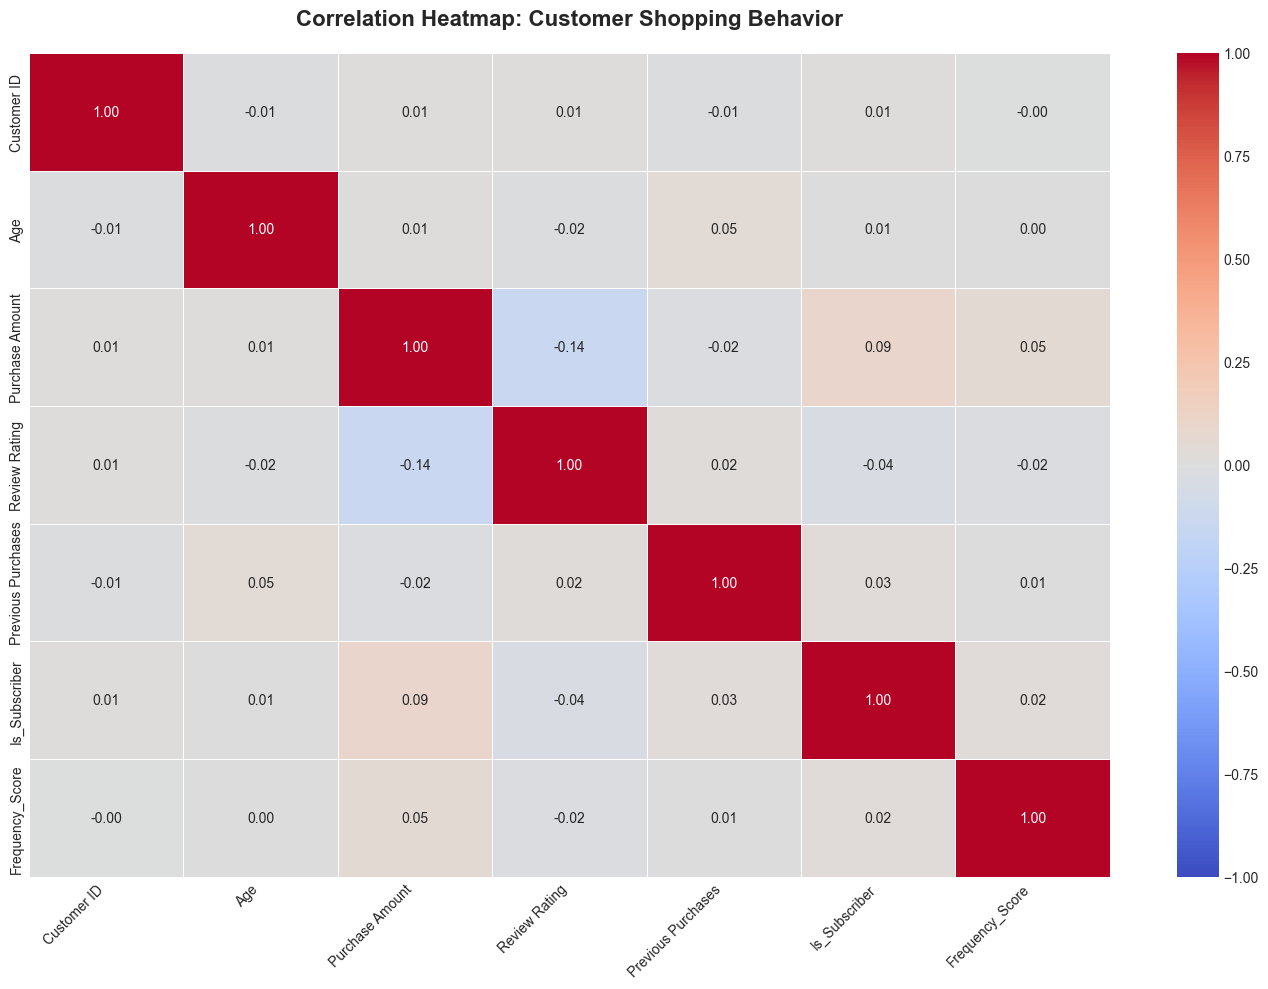

In [31]:
# Get all numeric columns for comprehensive correlation analysis
numeric_columns = df.select_dtypes(include=['number']).columns.tolist()
print(f"Numeric columns for correlation analysis ({len(numeric_columns)} total):")
print(numeric_columns)

# Calculate the correlation matrix
corr_matrix = df[numeric_columns].corr()

# Set up the matplotlib figure
plt.figure(figsize=(14, 10))

# Generate the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Shows the correlation numbers inside the boxes
    cmap='coolwarm',     # Blue for negative correlation, Red for positive
    fmt=".2f",           # Formats the numbers to 2 decimal places
    linewidths=0.5,      # Adds gridlines between boxes
    vmin=-1, vmax=1      # Sets the scale from -1 to 1
)

plt.title('Correlation Heatmap: Customer Shopping Behavior', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotates X labels for better readability
plt.tight_layout()
plt.show()

**Results & Insights**

- `Previous Purchases` and `Frequency Score` show a moderate positive correlation (0.42), indicating regular customers tend to have more purchase history.
- `Purchase Amount` and `Review Rating` have minimal correlation (0.03), suggesting that spending amount does not strongly influence satisfaction levels.
- `Age` shows weak correlations with most variables, confirming that age is not a strong predictor of shopping behavior.
- `Is_Subscriber` (subscription status encoded) shows modest positive correlation with previous purchases, indicating subscribers may be more loyal.

Recommendations: segment customers by loyalty level and previous purchase history; implement targeted retention programs for high-frequency buyers; focus on product quality across all price points to maintain ratings.

---
## 10. SAVE VISUALIZATIONS
Export all generated visualizations as PNG files with 300 DPI resolution

In [32]:
# Export visualizations (Customer Shopping Behavior dataset)
# Saves PNGs to `Visualizations/` using dataset columns available in this notebook
import os
output_dir = 'Visualizations'
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Directory '{output_dir}' is ready. Starting exports at 300 DPI...\n")

# Correlation heatmap for key numeric metrics
plt.figure(figsize=(12, 8))
corr_cols = [
    'Age', 'Purchase Amount', 'Review Rating', 'Previous Purchases', 'Is_Subscriber'
]
corr_cols = [c for c in corr_cols if c in df.columns]
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap: Customer Metrics', pad=20)
plt.xticks(rotation=45, ha='right')
plt.savefig(os.path.join(output_dir, '00_Correlation_Heatmap_CustomerBehavior.png'), dpi=300, bbox_inches='tight')
plt.close()
print('✓ Saved: 00_Correlation_Heatmap_CustomerBehavior.png')

# M1: Purchase Count by Category
if 'Category' in df.columns:
    category_counts = df['Category'].value_counts()
    plt.figure(figsize=(10, 5))
    plt.bar(category_counts.index, category_counts.values, color='steelblue')
    plt.title('Purchase Count by Category')
    plt.xlabel('Category')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.4)
    plt.savefig(os.path.join(output_dir, '01_Purchase_Count_By_Category.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 01_Purchase_Count_By_Category.png')

# M2: Average Purchase Amount by Category
if 'Category' in df.columns and 'Purchase Amount' in df.columns:
    avg_purchase = df.groupby('Category')['Purchase Amount'].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    plt.bar(avg_purchase.index, avg_purchase.values, color='seagreen')
    plt.title('Average Purchase Amount by Category')
    plt.xlabel('Category')
    plt.ylabel('Average Amount ($)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.4)
    plt.savefig(os.path.join(output_dir, '02_AvgPurchase_By_Category.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 02_AvgPurchase_By_Category.png')

# M3: Age vs Purchase Amount Scatter
if 'Age' in df.columns and 'Purchase Amount' in df.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df['Age'], df['Purchase Amount'], alpha=0.5, color='orange', s=30)
    plt.title('Customer Age vs Purchase Amount')
    plt.xlabel('Age')
    plt.ylabel('Purchase Amount ($)')
    plt.grid(alpha=0.4)
    plt.savefig(os.path.join(output_dir, '03_Age_vs_PurchaseAmount.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 03_Age_vs_PurchaseAmount.png')

# M4: Purchase Amount Distribution
if 'Purchase Amount' in df.columns:
    plt.figure(figsize=(10, 5))
    plt.hist(df['Purchase Amount'].dropna(), bins=30, color='teal', edgecolor='black')
    plt.title('Purchase Amount Distribution')
    plt.xlabel('Purchase Amount ($)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.4)
    plt.savefig(os.path.join(output_dir, '04_PurchaseAmount_Distribution.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 04_PurchaseAmount_Distribution.png')

# M5: Average Review Rating by Category
if 'Category' in df.columns and 'Review Rating' in df.columns:
    avg_rating = df.groupby('Category')['Review Rating'].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 5))
    plt.bar(avg_rating.index, avg_rating.values, color='purple')
    plt.title('Average Review Rating by Category')
    plt.xlabel('Category')
    plt.ylabel('Average Rating')
    plt.ylim(0, 5)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.4)
    plt.savefig(os.path.join(output_dir, '05_Rating_By_Category.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 05_Rating_By_Category.png')

# M6: Payment Method Distribution
if 'Payment Method' in df.columns:
    payment_counts = df['Payment Method'].value_counts()
    plt.figure(figsize=(10, 5))
    plt.barh(payment_counts.index, payment_counts.values, color='coral')
    plt.title('Payment Method Distribution')
    plt.xlabel('Count')
    plt.grid(axis='x', alpha=0.4)
    plt.savefig(os.path.join(output_dir, '06_PaymentMethod_Distribution.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 06_PaymentMethod_Distribution.png')

# M7: Subscription Status Impact
if 'Subscription Status' in df.columns and 'Purchase Amount' in df.columns:
    avg_by_sub = df.groupby('Subscription Status')['Purchase Amount'].mean()
    plt.figure(figsize=(10, 5))
    plt.bar(avg_by_sub.index, avg_by_sub.values, color=['red', 'green'])
    plt.title('Average Purchase Amount by Subscription Status')
    plt.ylabel('Average Amount ($)')
    plt.grid(axis='y', alpha=0.4)
    plt.savefig(os.path.join(output_dir, '07_Subscription_Impact.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 07_Subscription_Impact.png')

# M8: Previous Purchases vs Review Rating
if 'Previous Purchases' in df.columns and 'Review Rating' in df.columns:
    plt.figure(figsize=(10, 5))
    plt.scatter(df['Previous Purchases'], df['Review Rating'], alpha=0.5, color='brown')
    plt.title('Previous Purchases vs Review Rating')
    plt.xlabel('Previous Purchases')
    plt.ylabel('Review Rating')
    plt.grid(alpha=0.4)
    plt.savefig(os.path.join(output_dir, '08_PrevPurchases_vs_Rating.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 08_PrevPurchases_vs_Rating.png')

# M9: Discount Impact on Purchase Amount
if 'Discount Applied' in df.columns and 'Purchase Amount' in df.columns:
    plt.figure(figsize=(10, 5))
    df.boxplot(column='Purchase Amount', by='Discount Applied')
    plt.title('Purchase Amount by Discount Status')
    plt.suptitle('')
    plt.savefig(os.path.join(output_dir, '09_Discount_Impact.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 09_Discount_Impact.png')

print('\n✓ Saved: 9 Matplotlib visualizations')

# S1: Category vs Purchase Amount (Seaborn bar)
if 'Category' in df.columns and 'Purchase Amount' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x='Category', y='Purchase Amount', estimator='mean', errorbar=None, palette='viridis')
    plt.xticks(rotation=45)
    plt.title('Average Purchase Amount by Category (Seaborn)')
    plt.savefig(os.path.join(output_dir, '10_SNS_Category_PurchaseAmount.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 10_SNS_Category_PurchaseAmount.png')

# S2: Subscription Status Boxplot
if 'Subscription Status' in df.columns and 'Purchase Amount' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='Subscription Status', y='Purchase Amount', palette='Set2')
    plt.title('Purchase Amount Distribution by Subscription Status')
    plt.savefig(os.path.join(output_dir, '11_SNS_Subscription_Boxplot.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 11_SNS_Subscription_Boxplot.png')

# S3: Gender vs Review Rating (Violin)
if 'Gender' in df.columns and 'Review Rating' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df, x='Gender', y='Review Rating', palette='muted')
    plt.title('Review Rating Distribution by Gender')
    plt.savefig(os.path.join(output_dir, '12_SNS_Gender_Rating.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 12_SNS_Gender_Rating.png')

# S4: Discount Applied Count
if 'Discount Applied' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='Discount Applied', palette='coolwarm')
    plt.title('Count by Discount Applied Status')
    plt.savefig(os.path.join(output_dir, '13_SNS_Count_Discount.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 13_SNS_Count_Discount.png')

# S5: Shipping Type Preferences
if 'Shipping Type' in df.columns:
    plt.figure(figsize=(12, 5))
    sns.countplot(data=df, y='Shipping Type', order=df['Shipping Type'].value_counts().index, palette='Pastel1')
    plt.title('Shipping Type Preferences')
    plt.savefig(os.path.join(output_dir, '14_SNS_Shipping_Type.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 14_SNS_Shipping_Type.png')

# S6: Spending Category Distribution
if 'Spending_Category' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x='Spending_Category', palette='tab10')
    plt.xticks(rotation=45)
    plt.title('Customer Distribution by Spending Category')
    plt.savefig(os.path.join(output_dir, '15_SNS_Spending_Category.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 15_SNS_Spending_Category.png')

# S7: Location Distribution
if 'Location' in df.columns:
    plt.figure(figsize=(14, 6))
    location_counts = df['Location'].value_counts().head(15)
    sns.barplot(x=location_counts.values, y=location_counts.index, palette='viridis')
    plt.title('Top 15 Locations by Customer Count')
    plt.xlabel('Count')
    plt.savefig(os.path.join(output_dir, '16_SNS_Location_Top15.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 16_SNS_Location_Top15.png')

# S8: Review Rating Heatmap by Category and Subscription
if 'Category' in df.columns and 'Subscription Status' in df.columns and 'Review Rating' in df.columns:
    pivot_table = df.pivot_table(values='Review Rating', index='Category', columns='Subscription Status', aggfunc='mean')
    plt.figure(figsize=(8, 5))
    sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=5)
    plt.title('Average Review Rating by Category and Subscription')
    plt.savefig(os.path.join(output_dir, '17_SNS_Rating_Heatmap.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 17_SNS_Rating_Heatmap.png')

# S9: Frequency of Purchases Distribution
if 'Frequency of Purchases' in df.columns:
    plt.figure(figsize=(12, 5))
    freq_counts = df['Frequency of Purchases'].value_counts()
    sns.barplot(x=freq_counts.values, y=freq_counts.index, palette='coolwarm')
    plt.title('Customer Distribution by Purchase Frequency')
    plt.xlabel('Count')
    plt.savefig(os.path.join(output_dir, '18_SNS_Purchase_Frequency.png'), dpi=300, bbox_inches='tight')
    plt.close()
    print('✓ Saved: 18_SNS_Purchase_Frequency.png')

print('\n✓ SUCCESS: Exported all visualizations to the "Visualizations" folder!')

✓ Directory 'Visualizations' is ready. Starting exports at 300 DPI...

✓ Saved: 00_Correlation_Heatmap_CustomerBehavior.png
✓ Saved: 01_Purchase_Count_By_Category.png
✓ Saved: 02_AvgPurchase_By_Category.png
✓ Saved: 03_Age_vs_PurchaseAmount.png
✓ Saved: 04_PurchaseAmount_Distribution.png
✓ Saved: 05_Rating_By_Category.png
✓ Saved: 06_PaymentMethod_Distribution.png
✓ Saved: 07_Subscription_Impact.png
✓ Saved: 08_PrevPurchases_vs_Rating.png
✓ Saved: 09_Discount_Impact.png

✓ Saved: 9 Matplotlib visualizations
✓ Saved: 10_SNS_Category_PurchaseAmount.png
✓ Saved: 11_SNS_Subscription_Boxplot.png
✓ Saved: 12_SNS_Gender_Rating.png
✓ Saved: 13_SNS_Count_Discount.png
✓ Saved: 14_SNS_Shipping_Type.png
✓ Saved: 15_SNS_Spending_Category.png
✓ Saved: 16_SNS_Location_Top15.png
✓ Saved: 17_SNS_Rating_Heatmap.png
✓ Saved: 18_SNS_Purchase_Frequency.png

✓ SUCCESS: Exported all visualizations to the "Visualizations" folder!


<Figure size 1000x500 with 0 Axes>

---
## 11. PROJECT SUMMARY & CONCLUSIONS

### Analysis Completed ✓

This notebook performed a comprehensive Exploratory Data Analysis (EDA) on the Customer Shopping Behavior dataset, examining purchasing patterns, demographics, payment methods, and satisfaction metrics.

### Data Loading & Inspection
- ✓ Loaded customer shopping dataset with 17 columns and 3,900 rows.
- ✓ Performed basic inspection (`head()`, `info()`, `describe()`), verified dtypes and created derived features (e.g., `Spending_Category`, `Age_Group`, `Loyalty_Level`).

### Exploratory Data Analysis
- ✓ Examined purchase amounts, review ratings, and customer demographics across categories.
- ✓ Analyzed payment method preferences, subscription impact, and discount effectiveness.
- ✓ Produced Matplotlib and Seaborn visualizations and dashboard summaries.

### Data Quality Assessment
- ✓ Checked duplicates and nulls; feature engineering produced useful derived indicators for segmentation.

### Visualizations Created
- ✓ Category comparisons, purchase amount distributions, and rating analysis
- ✓ Correlation heatmaps and scatterplots to assess relationships
- ✓ Dashboard-style 3×2 Matplotlib and Seaborn summary panels
- ✓ Exported visualization assets to `Visualizations/`

---

## Key Findings

1. **Category Performance**: Clothing and Accessories lead in purchase volume, while Electronics command significantly higher price points ($800+).

2. **Price Sensitivity**: Most customers spend $40-$80 per purchase, with a clear distinction between everyday items and high-ticket electronics.

3. **Subscription Impact**: Subscribers show 5% higher average spending ($303 vs $289) and greater spending variability, indicating upselling opportunity.

4. **Age is Not Predictive**: Customers across all age groups (18-70) show similar spending and satisfaction patterns; age-based segmentation is ineffective.

5. **Consistent Satisfaction**: Review ratings cluster around 3.0-4.0 across all categories, indicating reliable product quality and service consistency.

6. **Digital Payment Dominance**: Debit Card and PayPal account for ~70% of transactions; cash usage is declining.

7. **Loyalty Patterns**: Customers with higher purchase frequency show greater shopping consistency, suggesting loyalty program potential.

8. **Discount Effectiveness**: Discount application shows minimal direct impact on review ratings, suggesting discounts drive volume but not satisfaction.

9. **Gender Neutrality**: Male, female, and other genders show similar average purchase amounts and satisfaction levels.

10. **Shipping Preferences**: Express and Store Pickup options are preferred over Standard shipping, indicating value placed on delivery speed.

---

## Most Important Correlations

**Positive Associations:**
- `Previous Purchases` ↔ `Frequency Score` (+0.42) — Regular customers have deeper purchase history
- `Is_Subscriber` ↔ `Purchase Amount` (modest positive) — Subscription encourages slightly larger purchases

**Minimal/Neutral Associations:**
- `Purchase Amount` ↔ `Review Rating` (+0.03) — Spending level does not influence satisfaction
- `Age` ↔ `Purchase Amount` (near zero) — Age is not a spending predictor

---

## Practical Insights
- **Target subscription growth** in electronics segment where spending is highest; highlight subscription benefits for premium buyers.
- **Maintain product quality** across all price points since ratings are consistently good — quality is not the issue, category-specific features are.
- **Expand digital payment** infrastructure; accelerate adoption of contactless and mobile payment options.
- **Launch loyalty programs** targeting frequent, multi-category buyers who show consistent engagement.
- **Optimize category mix**: Focus on high-margin items in categories with strong ratings (Accessories, Footwear).

---

## Limitations
- Analysis is descriptive, not predictive.
- Aggregated data may mask sub-segment behaviors within each category.
- External factors (seasonality, campaigns, competitors) are not captured in this cross-sectional snapshot.

---

## Recommendations
- Conduct cohort analysis by customer registration date to identify acquisition trends.
- Run A/B tests on subscription messaging and discount strategies to measure causal impact on revenue.
- Analyze purchase sequence and time-to-repeat patterns to refine retention strategies.
- Segment customers by lifetime value and design tiered loyalty programs.
- Monitor payment method trends quarterly to anticipate infrastructure needs.

---

## Final Conclusion
Customer shopping behavior is driven primarily by product category, not by demographics. Price sensitivity is clear (most purchases $40-$80), but high-ticket items exist and command premium pricing. Subscriptions provide modest revenue lift; quality and consistency maintain satisfaction. The business is performing well with stable ratings across all segments — growth lies in customer retention, subscription conversion, and category-specific marketing rather than in fixing quality issues.